In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

In [21]:
data = pd.read_csv('../M1_final.csv')

In [22]:
# Drop unnecessary features
data.drop(columns=['TAIL_NUM', 'DEP_TIME_M', 'TAXI_OUT'], inplace=True)

# create target variable
data['is_delayed'] = np.where(
    data['DEP_DELAY'] >= 15,
    1,
    0
)
data.drop(columns=['DEP_DELAY'], inplace=True)

# Drop null rows
data.dropna(inplace=True)

## Feature engineering

In [23]:
def get_time_of_day(minutes):
    if 300 <= minutes < 720:        # 5:00am - 11:59am
        return 'Morning'
    elif 720 <= minutes < 1020:     # 12:00pm - 4:59pm
        return 'Afternoon'
    elif 1020 <= minutes < 1260:    # 5:00pm - 8:59pm
        return 'Evening'
    else:                           # 9:00pm - 4:59am
        return 'Night'
    

data['time_of_day'] = data['CRS_DEP_M'].apply(get_time_of_day)


### Temporal lag feature

In [24]:
# Function to create temporal features
def create_temporal_features(df):

    df = df.copy()
    
    # Create a new date_order column to sort data according to date time
    df['date_order'] = df['MONTH'] * 100 + df['DAY_OF_MONTH']
    
    # Sort by destination, date, then departure time
    df = df.sort_values(["DEST", "date_order", "CRS_DEP_M"])
    
    # Previous flight delay at same destination
    df["prev_delay"] = df.groupby("DEST")["is_delayed"].shift(1)
    
    # Rolling delay rate over last 3 flights at same destination
    df["rolling_delay_rate_3"] = (
        df.groupby("DEST")["is_delayed"]
        .rolling(3, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    
    # Rolling delay rate over last 5 flights at same destination
    df["rolling_delay_rate_5"] = (
        df.groupby("DEST")["is_delayed"]
        .rolling(5, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    
    # Fill NaN values from the shift operation
    df["prev_delay"] = df["prev_delay"].fillna(0)
    
    # Drop temporary date_order column
    df = df.drop('date_order', axis=1)
    
    return df

## Stratified Train Test Split

In [25]:
# Stratified Train test split
from sklearn.model_selection import StratifiedShuffleSplit

x = data.drop('is_delayed', axis=1)
y = data['is_delayed']

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)

for train_index, test_index in splitter.split(data, data['is_delayed']):
    # Split the data first
    train_data = data.iloc[train_index].copy()
    test_data = data.iloc[test_index].copy()
    
    # Apply temporal features separately to avoid leakage
    train_data = create_temporal_features(train_data)
    test_data = create_temporal_features(test_data)
    
    # Now split into X and y
    x_train = train_data.drop('is_delayed', axis=1)
    y_train = train_data['is_delayed']
    x_test = test_data.drop('is_delayed', axis=1)
    y_test = test_data['is_delayed']

## Wind Direction Transformer

In [26]:
class WindDirectionTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column='Wind'):
        self.column = column
        self.wind_dict = {
            'NNW': 340, 'CALM': 0, 'NNE': 20, 'NE': 45, 'VAR': 0, 'WSW': 230, 
            'S': 180, 'SSW': 200, 'WNW': 290, 'ESE': 115, 'N': 360, 'SW': 225, 
            'E': 90, 'W': 270, 'SSE': 155, 'ENE': 70, 'NW': 315, 'SE': 135
        }

    def fit(self, X, y=None):
        return self
    

    def transform(self, X):
        X = X.copy()
        # Map wind directions to degrees
        X['wind_deg'] = X[self.column].map(self.wind_dict)
        # Convert to radians
        X['wind_rad'] = np.deg2rad(X['wind_deg'])
        #Compute sin and cos
        X['wind_sin'] = np.sin(X['wind_rad'])
        X['wind_cos'] = np.cos(X['wind_rad'])
        # Drop original columns
        X = X.drop(columns=[self.column, 'wind_deg', 'wind_rad'])
        return X

## Dew Point Transformer

In [27]:
class DewPointTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column='Dew Point'):
        self.column = column
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()

        # Clean column
        X[self.column] = (
            X[self.column].astype(str).str.replace('\xa0', '', regex=False).str.strip()
        )
        # Convert them into numeric values
        X[self.column] = pd.to_numeric(X[self.column], errors='coerce')

        return X

In [28]:
# ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('Wind transformer', WindDirectionTransformer(column='Wind'), ['Wind']),
    ('Dew Point Transformer', DewPointTransformer(column='Dew Point'), ['Dew Point']),
    ('OrdinalEncoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ['DEST', 'OP_UNIQUE_CARRIER', 'Condition']),
    ('OneHotEncoder', OneHotEncoder(handle_unknown='ignore', drop='first'), ['time_of_day'])
], remainder='passthrough')

## XGBoost Model

In [29]:
from xgboost import XGBClassifier

xgboost_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

## Create pipeline

In [30]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('Preprocessor', preprocessor),
    ('Train XGBoost', xgboost_model)
])

## Hyperparameter tuning with Optuna

In [31]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

In [32]:
def objective(trial):
    # Define hyperparameter search space
    params = {
        'Train XGBoost__n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'Train XGBoost__max_depth': trial.suggest_int('max_depth', 3, 10),
        'Train XGBoost__learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'Train XGBoost__subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'Train XGBoost__colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'Train XGBoost__min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'Train XGBoost__gamma': trial.suggest_float('gamma', 0, 0.5),
        'Train XGBoost__reg_alpha': trial.suggest_float('reg_alpha', 0, 1.0),
        'Train XGBoost__reg_lambda': trial.suggest_float('reg_lambda', 0, 1.0),
    }
    
    # Set parameters to the pipeline
    pipe.set_params(**params)
    
    # Perform cross-validation
    # Using accuracy as the metric
    cv_scores = cross_val_score(
        pipe, 
        x_train, 
        y_train, 
        cv=5, 
        scoring='accuracy',
        n_jobs=-1
    )
    
    # Return mean accuracy
    return cv_scores.mean()

In [33]:
# Create Optuna study
study = optuna.create_study(
    direction='maximize',  # Maximize accuracy
    study_name='XGBoost_Hyperparameter_Tuning',
    sampler=optuna.samplers.TPESampler(seed=42)
)

# Run optimization
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\n" + "="*50)
print("Optimization completed!")
print("="*50)

[I 2025-10-28 23:41:40,929] A new study created in memory with name: XGBoost_Hyperparameter_Tuning
  0%|          | 0/50 [00:00<?, ?it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:42] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:42] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:42] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:42]

[I 2025-10-28 23:41:43,575] Trial 0 finished with value: 0.9208817246711503 and parameters: {'n_estimators': 250, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'gamma': 0.02904180608409973, 'reg_alpha': 0.8661761457749352, 'reg_lambda': 0.6011150117432088}. Best is trial 0 with value: 0.9208817246711503.


/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:44] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:44] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:44] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:44] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2025-10-28 23:41:45,102] Trial 1 finished with value: 0.91508197668025 and parameters: {'n_estimators': 383, 'max_depth': 3, 'learning_rate': 0.2708160864249968, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'min_child_weight': 2, 'gamma': 0.09170225492671691, 'reg_alpha': 0.3042422429595377, 'reg_lambda': 0.5247564316322378}. Best is trial 0 with value: 0.9208817246711503.


/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:46] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:46] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 0. Best value: 0.920882:   6%|▌         | 3/50 [00:05<01:20,  1.72s/it]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:46] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:46] WARNING: /workspace/src/learner.cc:738: 
Parameters: 

[I 2025-10-28 23:41:46,500] Trial 2 finished with value: 0.915924394812618 and parameters: {'n_estimators': 273, 'max_depth': 5, 'learning_rate': 0.08012737503998542, 'subsample': 0.6557975442608167, 'colsample_bytree': 0.7168578594140873, 'min_child_weight': 4, 'gamma': 0.22803499210851796, 'reg_alpha': 0.7851759613930136, 'reg_lambda': 0.19967378215835974}. Best is trial 0 with value: 0.9208817246711503.


Best trial: 0. Best value: 0.920882:   8%|▊         | 4/50 [00:06<01:02,  1.36s/it]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:47] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:47] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:47] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:47] WARNING: /workspace/src/learner.cc:738: 
Parameters: 

[I 2025-10-28 23:41:47,322] Trial 3 finished with value: 0.9117106331006765 and parameters: {'n_estimators': 306, 'max_depth': 7, 'learning_rate': 0.011711509955524094, 'subsample': 0.8430179407605753, 'colsample_bytree': 0.6682096494749166, 'min_child_weight': 1, 'gamma': 0.4744427686266666, 'reg_alpha': 0.9656320330745594, 'reg_lambda': 0.8083973481164611}. Best is trial 0 with value: 0.9208817246711503.


Best trial: 0. Best value: 0.920882:  10%|█         | 5/50 [00:06<00:46,  1.04s/it]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:47] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:47] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:47] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:47] WARNING: /workspace/src/learner.cc:738: 
Parameters: 

[I 2025-10-28 23:41:47,782] Trial 4 finished with value: 0.9089841059789803 and parameters: {'n_estimators': 222, 'max_depth': 3, 'learning_rate': 0.1024932221692416, 'subsample': 0.7760609974958406, 'colsample_bytree': 0.6488152939379115, 'min_child_weight': 5, 'gamma': 0.017194260557609198, 'reg_alpha': 0.9093204020787821, 'reg_lambda': 0.2587799816000169}. Best is trial 0 with value: 0.9208817246711503.


Best trial: 0. Best value: 0.920882:  12%|█▏        | 6/50 [00:07<00:40,  1.07it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:48] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:48] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:48] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:48] WARNING: /workspace/src/learner.cc:738: 
Parameters: 

[I 2025-10-28 23:41:48,504] Trial 5 finished with value: 0.9190474522936698 and parameters: {'n_estimators': 365, 'max_depth': 5, 'learning_rate': 0.05864129169696527, 'subsample': 0.8186841117373118, 'colsample_bytree': 0.6739417822102108, 'min_child_weight': 10, 'gamma': 0.3875664116805573, 'reg_alpha': 0.9394989415641891, 'reg_lambda': 0.8948273504276488}. Best is trial 0 with value: 0.9208817246711503.


Best trial: 0. Best value: 0.920882:  14%|█▍        | 7/50 [00:08<00:42,  1.02it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:49] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:49] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:49] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:49] WARNING: /workspace/src/learner.cc:738: 
Parameters: 

[I 2025-10-28 23:41:49,579] Trial 6 finished with value: 0.916420106910345 and parameters: {'n_estimators': 339, 'max_depth': 10, 'learning_rate': 0.01351182947645082, 'subsample': 0.6783931449676581, 'colsample_bytree': 0.6180909155642152, 'min_child_weight': 4, 'gamma': 0.194338644844741, 'reg_alpha': 0.2713490317738959, 'reg_lambda': 0.8287375091519293}. Best is trial 0 with value: 0.9208817246711503.


Best trial: 0. Best value: 0.920882:  16%|█▌        | 8/50 [00:09<00:35,  1.17it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:50] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:50] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:50] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:50] WARNING: /workspace/src/learner.cc:738: 
Parameters: 

[I 2025-10-28 23:41:50,171] Trial 7 finished with value: 0.9147349143187491 and parameters: {'n_estimators': 243, 'max_depth': 5, 'learning_rate': 0.06333268775321842, 'subsample': 0.6563696899899051, 'colsample_bytree': 0.9208787923016158, 'min_child_weight': 1, 'gamma': 0.49344346830025865, 'reg_alpha': 0.7722447692966574, 'reg_lambda': 0.1987156815341724}. Best is trial 0 with value: 0.9208817246711503.


Best trial: 0. Best value: 0.920882:  18%|█▊        | 9/50 [00:09<00:31,  1.32it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:50] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:50] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:50] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:50] WARNING: /workspace/src/learner.cc:738: 
Parameters: 

[I 2025-10-28 23:41:50,723] Trial 8 finished with value: 0.9170650708138199 and parameters: {'n_estimators': 102, 'max_depth': 9, 'learning_rate': 0.11069143219393454, 'subsample': 0.8916028672163949, 'colsample_bytree': 0.9085081386743783, 'min_child_weight': 1, 'gamma': 0.1792328642721363, 'reg_alpha': 0.11586905952512971, 'reg_lambda': 0.8631034258755935}. Best is trial 0 with value: 0.9208817246711503.


Best trial: 0. Best value: 0.920882:  20%|██        | 10/50 [00:10<00:29,  1.36it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:51] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:51] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:51] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:51] WARNING: /workspace/src/learner.cc:738: 
Parameters:

[I 2025-10-28 23:41:51,399] Trial 9 finished with value: 0.9072484992802812 and parameters: {'n_estimators': 349, 'max_depth': 5, 'learning_rate': 0.012413189635294229, 'subsample': 0.7243929286862649, 'colsample_bytree': 0.7300733288106989, 'min_child_weight': 8, 'gamma': 0.31877873567760656, 'reg_alpha': 0.8872127425763265, 'reg_lambda': 0.4722149251619493}. Best is trial 0 with value: 0.9208817246711503.


Best trial: 10. Best value: 0.921279:  22%|██▏       | 11/50 [00:11<00:33,  1.15it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:52] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:52] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:52] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:52] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:41:52,576] Trial 10 finished with value: 0.9212785007731679 and parameters: {'n_estimators': 478, 'max_depth': 8, 'learning_rate': 0.028477486830279865, 'subsample': 0.9729161367647149, 'colsample_bytree': 0.8085360047450805, 'min_child_weight': 7, 'gamma': 0.007572118551378439, 'reg_alpha': 0.6233765186294654, 'reg_lambda': 0.5705478648816833}. Best is trial 10 with value: 0.9212785007731679.


Best trial: 10. Best value: 0.921279:  24%|██▍       | 12/50 [00:12<00:36,  1.03it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:53] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:53] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:53] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:53] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:41:53,769] Trial 11 finished with value: 0.9199895313626001 and parameters: {'n_estimators': 499, 'max_depth': 8, 'learning_rate': 0.026220976364771588, 'subsample': 0.9845355085773861, 'colsample_bytree': 0.8243626807262747, 'min_child_weight': 7, 'gamma': 0.005511196749239478, 'reg_alpha': 0.5732909776512292, 'reg_lambda': 0.5916836359300597}. Best is trial 10 with value: 0.9212785007731679.


Best trial: 10. Best value: 0.921279:  26%|██▌       | 13/50 [00:14<00:41,  1.11s/it]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:55] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:55] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:55] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:55] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:41:55,215] Trial 12 finished with value: 0.9204356280168751 and parameters: {'n_estimators': 476, 'max_depth': 10, 'learning_rate': 0.03163393826748552, 'subsample': 0.9987966992361725, 'colsample_bytree': 0.7875197249298348, 'min_child_weight': 7, 'gamma': 0.1041401330544119, 'reg_alpha': 0.5855038899618592, 'reg_lambda': 0.6561163985808629}. Best is trial 10 with value: 0.9212785007731679.


Best trial: 10. Best value: 0.921279:  28%|██▊       | 14/50 [00:14<00:34,  1.06it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:55] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:55] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:55] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:55] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:41:55,778] Trial 13 finished with value: 0.9207327554694636 and parameters: {'n_estimators': 171, 'max_depth': 8, 'learning_rate': 0.23586553545554326, 'subsample': 0.8923645209213664, 'colsample_bytree': 0.8340263727840078, 'min_child_weight': 9, 'gamma': 0.09453049307333258, 'reg_alpha': 0.6882295119501993, 'reg_lambda': 0.41814076162776753}. Best is trial 10 with value: 0.9212785007731679.


Best trial: 10. Best value: 0.921279:  30%|███       | 15/50 [00:16<00:35,  1.03s/it]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:57] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:57] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:57] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:57] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:41:56,991] Trial 14 finished with value: 0.9204847151136037 and parameters: {'n_estimators': 417, 'max_depth': 9, 'learning_rate': 0.15754911501411575, 'subsample': 0.7664125867669591, 'colsample_bytree': 0.997586518402149, 'min_child_weight': 3, 'gamma': 0.049302866058105174, 'reg_alpha': 0.40732326372387984, 'reg_lambda': 0.7049270826015107}. Best is trial 10 with value: 0.9212785007731679.


Best trial: 10. Best value: 0.921279:  32%|███▏      | 16/50 [00:17<00:36,  1.07s/it]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:58] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:58] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:58] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:58] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:41:58,145] Trial 15 finished with value: 0.918700414506435 and parameters: {'n_estimators': 442, 'max_depth': 7, 'learning_rate': 0.03293609248277876, 'subsample': 0.6043956756975085, 'colsample_bytree': 0.7709127163615966, 'min_child_weight': 6, 'gamma': 0.15143561459664853, 'reg_alpha': 0.6705451426048865, 'reg_lambda': 0.3817170010037741}. Best is trial 10 with value: 0.9212785007731679.


Best trial: 10. Best value: 0.921279:  34%|███▍      | 17/50 [00:17<00:30,  1.08it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:58] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:58] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:58] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:58] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:41:58,742] Trial 16 finished with value: 0.9159244685354168 and parameters: {'n_estimators': 173, 'max_depth': 9, 'learning_rate': 0.021739299178637067, 'subsample': 0.9344291259107609, 'colsample_bytree': 0.8806358517713622, 'min_child_weight': 6, 'gamma': 0.2885630226010409, 'reg_alpha': 0.5111155499269745, 'reg_lambda': 0.013179214380923454}. Best is trial 10 with value: 0.9212785007731679.


Best trial: 10. Best value: 0.921279:  36%|███▌      | 18/50 [00:18<00:29,  1.09it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:59] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:59] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:59] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:41:59] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:41:59,653] Trial 17 finished with value: 0.9196923056129467 and parameters: {'n_estimators': 299, 'max_depth': 8, 'learning_rate': 0.04323444823345438, 'subsample': 0.864084442383738, 'colsample_bytree': 0.746538762018675, 'min_child_weight': 3, 'gamma': 0.07258965692300268, 'reg_alpha': 0.795692910920105, 'reg_lambda': 0.9910985934143602}. Best is trial 10 with value: 0.9212785007731679.


Best trial: 18. Best value: 0.921625:  38%|███▊      | 19/50 [00:19<00:26,  1.17it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:00] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:00] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:00] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:00] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:42:00,347] Trial 18 finished with value: 0.9216250102136794 and parameters: {'n_estimators': 204, 'max_depth': 10, 'learning_rate': 0.1623818493172483, 'subsample': 0.940580021335946, 'colsample_bytree': 0.6075934324519439, 'min_child_weight': 8, 'gamma': 0.14256580031003452, 'reg_alpha': 0.7017239465576907, 'reg_lambda': 0.7038908187856383}. Best is trial 18 with value: 0.9216250102136794.


Best trial: 18. Best value: 0.921625:  40%|████      | 20/50 [00:19<00:22,  1.33it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:00] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:00] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:00] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:00] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:42:00,862] Trial 19 finished with value: 0.9096778620879894 and parameters: {'n_estimators': 189, 'max_depth': 6, 'learning_rate': 0.01983528680174693, 'subsample': 0.9440357002920831, 'colsample_bytree': 0.8564414747526364, 'min_child_weight': 8, 'gamma': 0.12079171308839437, 'reg_alpha': 0.4181540822820741, 'reg_lambda': 0.7203853685502786}. Best is trial 18 with value: 0.9216250102136794.


Best trial: 18. Best value: 0.921625:  42%|████▏     | 21/50 [00:20<00:19,  1.49it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:01] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:01] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:01] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:01] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:42:01,352] Trial 20 finished with value: 0.9203857914050275 and parameters: {'n_estimators': 119, 'max_depth': 9, 'learning_rate': 0.1859011281635771, 'subsample': 0.9531581375124991, 'colsample_bytree': 0.6060084846502749, 'min_child_weight': 10, 'gamma': 0.23603541424794372, 'reg_alpha': 0.01162096162755305, 'reg_lambda': 0.34702385380450146}. Best is trial 18 with value: 0.9216250102136794.


Best trial: 21. Best value: 0.922369:  44%|████▍     | 22/50 [00:21<00:19,  1.44it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:02] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:02] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:02] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:02] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:42:02,101] Trial 21 finished with value: 0.9223685414988705 and parameters: {'n_estimators': 230, 'max_depth': 10, 'learning_rate': 0.14837115356414138, 'subsample': 0.8945172351954433, 'colsample_bytree': 0.6372104459169725, 'min_child_weight': 8, 'gamma': 0.04079601082070598, 'reg_alpha': 0.7064325006189424, 'reg_lambda': 0.5628308336403138}. Best is trial 21 with value: 0.9223685414988705.


Best trial: 21. Best value: 0.922369:  46%|████▌     | 23/50 [00:21<00:18,  1.43it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:02] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:02] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:02] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:02] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:42:02,814] Trial 22 finished with value: 0.9202865482309907 and parameters: {'n_estimators': 199, 'max_depth': 10, 'learning_rate': 0.1458572154524829, 'subsample': 0.9015531487992562, 'colsample_bytree': 0.6221755001456812, 'min_child_weight': 8, 'gamma': 0.15299058088083473, 'reg_alpha': 0.6846645614534533, 'reg_lambda': 0.5470210833097098}. Best is trial 21 with value: 0.9223685414988705.


Best trial: 21. Best value: 0.922369:  48%|████▊     | 24/50 [00:22<00:16,  1.55it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:03] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:03] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:03] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:03] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:42:03,328] Trial 23 finished with value: 0.9213772033133484 and parameters: {'n_estimators': 144, 'max_depth': 8, 'learning_rate': 0.21679214861105647, 'subsample': 0.9761481011191779, 'colsample_bytree': 0.6985397605734611, 'min_child_weight': 9, 'gamma': 0.0012823431313636613, 'reg_alpha': 0.6343917528326504, 'reg_lambda': 0.7510882509824126}. Best is trial 21 with value: 0.9223685414988705.


Best trial: 21. Best value: 0.922369:  50%|█████     | 25/50 [00:22<00:14,  1.69it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:03] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:03] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:03] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:03] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:42:03,800] Trial 24 finished with value: 0.9190969202915245 and parameters: {'n_estimators': 146, 'max_depth': 9, 'learning_rate': 0.20854346372081906, 'subsample': 0.9099890979200697, 'colsample_bytree': 0.638511324128068, 'min_child_weight': 9, 'gamma': 0.046684844062278186, 'reg_alpha': 0.5230341322632872, 'reg_lambda': 0.7559496543168278}. Best is trial 21 with value: 0.9223685414988705.


Best trial: 21. Best value: 0.922369:  52%|█████▏    | 26/50 [00:23<00:14,  1.71it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:04] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:04] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:04] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:04] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:42:04,367] Trial 25 finished with value: 0.9199890153030099 and parameters: {'n_estimators': 147, 'max_depth': 10, 'learning_rate': 0.276735711954287, 'subsample': 0.8654966735891229, 'colsample_bytree': 0.7088548339714549, 'min_child_weight': 9, 'gamma': 0.12759381648330584, 'reg_alpha': 0.7477018925280586, 'reg_lambda': 0.9425776478421788}. Best is trial 21 with value: 0.9223685414988705.


Best trial: 21. Best value: 0.922369:  54%|█████▍    | 27/50 [00:24<00:13,  1.71it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:05] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:05] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:05] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:05] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:42:04,957] Trial 26 finished with value: 0.9214763481903203 and parameters: {'n_estimators': 203, 'max_depth': 7, 'learning_rate': 0.16230621538422435, 'subsample': 0.9587918363548115, 'colsample_bytree': 0.7001241988501505, 'min_child_weight': 10, 'gamma': 0.06326134468561778, 'reg_alpha': 0.4329290625024344, 'reg_lambda': 0.6589572386665475}. Best is trial 21 with value: 0.9223685414988705.


Best trial: 21. Best value: 0.922369:  56%|█████▌    | 28/50 [00:24<00:12,  1.82it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:05] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:05] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:05] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:05] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:42:05,422] Trial 27 finished with value: 0.9129996147983774 and parameters: {'n_estimators': 221, 'max_depth': 4, 'learning_rate': 0.09022128677224969, 'subsample': 0.9249024827162747, 'colsample_bytree': 0.6004457694194595, 'min_child_weight': 10, 'gamma': 0.06717828342636595, 'reg_alpha': 0.4288084220895494, 'reg_lambda': 0.48203149465558254}. Best is trial 21 with value: 0.9223685414988705.


Best trial: 21. Best value: 0.922369:  58%|█████▊    | 29/50 [00:25<00:12,  1.69it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:06] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:06] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:06] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:06] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:42:06,109] Trial 28 finished with value: 0.9206337088895564 and parameters: {'n_estimators': 282, 'max_depth': 6, 'learning_rate': 0.14593071665432988, 'subsample': 0.8722837454363156, 'colsample_bytree': 0.6401118407645309, 'min_child_weight': 8, 'gamma': 0.19434381698678993, 'reg_alpha': 0.2597592713751957, 'reg_lambda': 0.6498925446707976}. Best is trial 21 with value: 0.9223685414988705.


Best trial: 21. Best value: 0.922369:  60%|██████    | 30/50 [00:25<00:12,  1.62it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:06] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:06] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:06] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:06] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:42:06,787] Trial 29 finished with value: 0.922269716087359 and parameters: {'n_estimators': 246, 'max_depth': 7, 'learning_rate': 0.1255002946004944, 'subsample': 0.9624709252049083, 'colsample_bytree': 0.7428088413842773, 'min_child_weight': 10, 'gamma': 0.1488278107194263, 'reg_alpha': 0.8398384561816132, 'reg_lambda': 0.6492485960558174}. Best is trial 21 with value: 0.9223685414988705.


Best trial: 30. Best value: 0.922716:  62%|██████▏   | 31/50 [00:26<00:12,  1.47it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:07] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:07] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:07] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:07] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:42:07,621] Trial 30 finished with value: 0.9227157021574361 and parameters: {'n_estimators': 252, 'max_depth': 10, 'learning_rate': 0.07223176767342016, 'subsample': 0.8192568734369868, 'colsample_bytree': 0.7548894045464258, 'min_child_weight': 7, 'gamma': 0.27608260932918505, 'reg_alpha': 0.8446143642226983, 'reg_lambda': 0.6351980732723772}. Best is trial 30 with value: 0.9227157021574361.


Best trial: 30. Best value: 0.922716:  64%|██████▍   | 32/50 [00:27<00:13,  1.35it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:08] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:08] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:08] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:08] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:42:08,499] Trial 31 finished with value: 0.9212286518741871 and parameters: {'n_estimators': 246, 'max_depth': 10, 'learning_rate': 0.08094538137872637, 'subsample': 0.8058240494110457, 'colsample_bytree': 0.7577271968441266, 'min_child_weight': 7, 'gamma': 0.2787600610872775, 'reg_alpha': 0.8521482557007041, 'reg_lambda': 0.6174796032752187}. Best is trial 30 with value: 0.9227157021574361.


Best trial: 30. Best value: 0.922716:  66%|██████▌   | 33/50 [00:28<00:12,  1.31it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:09] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:09] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:09] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:09] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:42:09,307] Trial 32 finished with value: 0.9224185747048477 and parameters: {'n_estimators': 274, 'max_depth': 9, 'learning_rate': 0.12704967816531737, 'subsample': 0.8283935785746819, 'colsample_bytree': 0.7874046912991868, 'min_child_weight': 6, 'gamma': 0.3486830868508632, 'reg_alpha': 0.842068049577956, 'reg_lambda': 0.5002439647129592}. Best is trial 30 with value: 0.9227157021574361.


Best trial: 30. Best value: 0.922716:  68%|██████▊   | 34/50 [00:29<00:12,  1.30it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:10] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:10] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:10] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:10] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:42:10,096] Trial 33 finished with value: 0.9221706080717864 and parameters: {'n_estimators': 268, 'max_depth': 9, 'learning_rate': 0.12190742940878758, 'subsample': 0.8273153765590744, 'colsample_bytree': 0.7872432691740117, 'min_child_weight': 5, 'gamma': 0.35242725488386417, 'reg_alpha': 0.9988944781163714, 'reg_lambda': 0.4885701019337034}. Best is trial 30 with value: 0.9227157021574361.


Best trial: 30. Best value: 0.922716:  70%|███████   | 35/50 [00:30<00:12,  1.20it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:11] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:11] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:11] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:11] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:42:11,081] Trial 34 finished with value: 0.9226663816051788 and parameters: {'n_estimators': 315, 'max_depth': 10, 'learning_rate': 0.07370658239243565, 'subsample': 0.7835007939697364, 'colsample_bytree': 0.7396715958147336, 'min_child_weight': 6, 'gamma': 0.4139082292878378, 'reg_alpha': 0.8323460722650038, 'reg_lambda': 0.43209084580708546}. Best is trial 30 with value: 0.9227157021574361.


Best trial: 30. Best value: 0.922716:  72%|███████▏  | 36/50 [00:31<00:12,  1.11it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:12] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:12] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:12] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:12] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:42:12,134] Trial 35 finished with value: 0.9206835946499365 and parameters: {'n_estimators': 316, 'max_depth': 10, 'learning_rate': 0.04526019063716522, 'subsample': 0.7753244275095081, 'colsample_bytree': 0.7636804525004821, 'min_child_weight': 6, 'gamma': 0.42999108322521623, 'reg_alpha': 0.829020193584777, 'reg_lambda': 0.2745171391685709}. Best is trial 30 with value: 0.9227157021574361.


Best trial: 30. Best value: 0.922716:  74%|███████▍  | 37/50 [00:32<00:12,  1.07it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:13] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:13] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:13] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:13] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:42:13,155] Trial 36 finished with value: 0.9208321460890977 and parameters: {'n_estimators': 331, 'max_depth': 9, 'learning_rate': 0.06416807006494447, 'subsample': 0.7424026078660915, 'colsample_bytree': 0.6834996214474333, 'min_child_weight': 5, 'gamma': 0.4002217089272051, 'reg_alpha': 0.910889185717536, 'reg_lambda': 0.4204601613023391}. Best is trial 30 with value: 0.9227157021574361.


Best trial: 30. Best value: 0.922716:  76%|███████▌  | 38/50 [00:33<00:12,  1.00s/it]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:14] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:14] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:14] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:14] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:42:14,312] Trial 37 finished with value: 0.9218236685816164 and parameters: {'n_estimators': 384, 'max_depth': 10, 'learning_rate': 0.09343695989381412, 'subsample': 0.84305224765946, 'colsample_bytree': 0.721903260993927, 'min_child_weight': 6, 'gamma': 0.3515449976604257, 'reg_alpha': 0.7456327006403946, 'reg_lambda': 0.5326455523827031}. Best is trial 30 with value: 0.9227157021574361.


Best trial: 30. Best value: 0.922716:  78%|███████▊  | 39/50 [00:34<00:10,  1.01it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:15] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:15] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:15] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:15] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:42:15,272] Trial 38 finished with value: 0.9206834103429401 and parameters: {'n_estimators': 282, 'max_depth': 10, 'learning_rate': 0.0718837610349438, 'subsample': 0.7977242510924639, 'colsample_bytree': 0.6588330238780691, 'min_child_weight': 4, 'gamma': 0.4404490110182907, 'reg_alpha': 0.9875668214277844, 'reg_lambda': 0.29488331741605384}. Best is trial 30 with value: 0.9227157021574361.


Best trial: 30. Best value: 0.922716:  80%|████████  | 40/50 [00:35<00:09,  1.04it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:16] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:16] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:16] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:16] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:42:16,183] Trial 39 finished with value: 0.920336593724101 and parameters: {'n_estimators': 263, 'max_depth': 9, 'learning_rate': 0.05159544851163018, 'subsample': 0.7173777010613931, 'colsample_bytree': 0.8079545074411126, 'min_child_weight': 5, 'gamma': 0.26910262439469956, 'reg_alpha': 0.9334975661223182, 'reg_lambda': 0.17763982518929322}. Best is trial 30 with value: 0.9227157021574361.


Best trial: 30. Best value: 0.922716:  82%|████████▏ | 41/50 [00:36<00:08,  1.07it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:17] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:17] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:17] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:17] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:42:17,037] Trial 40 finished with value: 0.921228885329716 and parameters: {'n_estimators': 226, 'max_depth': 10, 'learning_rate': 0.0994766321381406, 'subsample': 0.8436473264896195, 'colsample_bytree': 0.8561872941165407, 'min_child_weight': 7, 'gamma': 0.3170666465396421, 'reg_alpha': 0.8035503420712896, 'reg_lambda': 0.448490828781637}. Best is trial 30 with value: 0.9227157021574361.


Best trial: 30. Best value: 0.922716:  84%|████████▍ | 42/50 [00:36<00:07,  1.11it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:17] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:17] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:18] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:18] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:42:17,852] Trial 41 finished with value: 0.9223192455208793 and parameters: {'n_estimators': 297, 'max_depth': 6, 'learning_rate': 0.12909573338726826, 'subsample': 0.8054263074219203, 'colsample_bytree': 0.7366853255564064, 'min_child_weight': 6, 'gamma': 0.21213222585511637, 'reg_alpha': 0.8466457392826143, 'reg_lambda': 0.5967206007928368}. Best is trial 30 with value: 0.9227157021574361.


Best trial: 30. Best value: 0.922716:  86%|████████▌ | 43/50 [00:37<00:06,  1.15it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:18] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:18] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:18] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:18] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:42:18,652] Trial 42 finished with value: 0.9213282022265513 and parameters: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.07677016344661793, 'subsample': 0.7992083353426868, 'colsample_bytree': 0.7313317221979606, 'min_child_weight': 6, 'gamma': 0.37172686954251044, 'reg_alpha': 0.8639341332822024, 'reg_lambda': 0.5300336019308198}. Best is trial 30 with value: 0.9227157021574361.


Best trial: 30. Best value: 0.922716:  88%|████████▊ | 44/50 [00:38<00:04,  1.24it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:19] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:19] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:19] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:19] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:42:19,312] Trial 43 finished with value: 0.9172132413518549 and parameters: {'n_estimators': 323, 'max_depth': 4, 'learning_rate': 0.12127384151003522, 'subsample': 0.7600448870412589, 'colsample_bytree': 0.6759618790141958, 'min_child_weight': 7, 'gamma': 0.33101642071763226, 'reg_alpha': 0.7429722378227307, 'reg_lambda': 0.5969671374303158}. Best is trial 30 with value: 0.9227157021574361.


Best trial: 30. Best value: 0.922716:  90%|█████████ | 45/50 [00:39<00:04,  1.18it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:20] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:20] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:20] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:20] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:42:20,251] Trial 44 finished with value: 0.9198902144657646 and parameters: {'n_estimators': 383, 'max_depth': 6, 'learning_rate': 0.10673727338805103, 'subsample': 0.820924969083555, 'colsample_bytree': 0.7765323383273933, 'min_child_weight': 5, 'gamma': 0.2111202833418439, 'reg_alpha': 0.900176216410873, 'reg_lambda': 0.3589540991346433}. Best is trial 30 with value: 0.9227157021574361.


Best trial: 30. Best value: 0.922716:  92%|█████████▏| 46/50 [00:40<00:03,  1.09it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:21] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:21] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:21] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:21] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:42:21,336] Trial 45 finished with value: 0.920584376050166 and parameters: {'n_estimators': 356, 'max_depth': 9, 'learning_rate': 0.08598818276209508, 'subsample': 0.7969720868177983, 'colsample_bytree': 0.8246714952535326, 'min_child_weight': 6, 'gamma': 0.4142002593155158, 'reg_alpha': 0.9334362989107885, 'reg_lambda': 0.5127215047369208}. Best is trial 30 with value: 0.9227157021574361.


Best trial: 30. Best value: 0.922716:  94%|█████████▍| 47/50 [00:41<00:02,  1.16it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:22] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:22] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:22] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:22] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:42:22,057] Trial 46 finished with value: 0.9180563967122088 and parameters: {'n_estimators': 290, 'max_depth': 5, 'learning_rate': 0.05400539541651456, 'subsample': 0.7472974225950907, 'colsample_bytree': 0.7947217144183071, 'min_child_weight': 4, 'gamma': 0.47508144839054106, 'reg_alpha': 0.7807918493644694, 'reg_lambda': 0.802458512654821}. Best is trial 30 with value: 0.9227157021574361.


Best trial: 30. Best value: 0.922716:  96%|█████████▌| 48/50 [00:41<00:01,  1.16it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:23] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:23] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:23] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:23] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:42:22,921] Trial 47 finished with value: 0.921228639587054 and parameters: {'n_estimators': 228, 'max_depth': 10, 'learning_rate': 0.06974173838924626, 'subsample': 0.7117108165105803, 'colsample_bytree': 0.7462429925348242, 'min_child_weight': 7, 'gamma': 0.254952062728579, 'reg_alpha': 0.8688972330019439, 'reg_lambda': 0.578487781796841}. Best is trial 30 with value: 0.9227157021574361.


Best trial: 30. Best value: 0.922716:  98%|█████████▊| 49/50 [00:42<00:00,  1.26it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:23] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:23] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:23] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:23] WARNING: /workspace/src/learner.cc:738: 
Parameters

[I 2025-10-28 23:42:23,566] Trial 48 finished with value: 0.9213772770361469 and parameters: {'n_estimators': 259, 'max_depth': 7, 'learning_rate': 0.1895863944926373, 'subsample': 0.8590063249066712, 'colsample_bytree': 0.7181496538008467, 'min_child_weight': 7, 'gamma': 0.37865060642941006, 'reg_alpha': 0.9553749775102311, 'reg_lambda': 0.43640437710245894}. Best is trial 30 with value: 0.9227157021574361.


Best trial: 30. Best value: 0.922716: 100%|██████████| 50/50 [00:43<00:00,  1.15it/s]

[I 2025-10-28 23:42:24,463] Trial 49 finished with value: 0.9221706449331857 and parameters: {'n_estimators': 313, 'max_depth': 8, 'learning_rate': 0.1376331886218744, 'subsample': 0.8837832574580887, 'colsample_bytree': 0.6947381232368777, 'min_child_weight': 6, 'gamma': 0.32878969614311127, 'reg_alpha': 0.8225559133545074, 'reg_lambda': 0.3911014815944346}. Best is trial 30 with value: 0.9227157021574361.

Optimization completed!


## Results

In [34]:
# Display best parameters
print("Best Trial:")
print(f"  Value (Accuracy): {study.best_trial.value:.4f}")
print(f"  Number: {study.best_trial.number}")
print("\nBest Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

Best Trial:
  Value (Accuracy): 0.9227
  Number: 30

Best Hyperparameters:
  n_estimators: 252
  max_depth: 10
  learning_rate: 0.07223176767342016
  subsample: 0.8192568734369868
  colsample_bytree: 0.7548894045464258
  min_child_weight: 7
  gamma: 0.27608260932918505
  reg_alpha: 0.8446143642226983
  reg_lambda: 0.6351980732723772


## Training the model with best hyper parameters

In [35]:
# Train final model with best parameters
best_params_with_prefix = {f'Train XGBoost__{key}': value for key, value in study.best_params.items()}
pipe.set_params(**best_params_with_prefix)

# Fit the model
print("Training final model with best parameters...")
pipe.fit(x_train, y_train)

/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:42:24] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training final model with best parameters...


,steps,"[('Preprocessor', ...), ('Train XGBoost', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Wind transformer', ...), ('Dew Point Transformer', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Evaluating on test set

In [36]:
# Make predictions on test set
y_pred = pipe.predict(x_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("="*50)
print("Test Set Performance")
print("="*50)
print(f"Accuracy:  {100 * accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("="*50)

Test Set Performance
Accuracy:  94.4599
Precision: 0.7997
Recall:    0.8043
F1 Score:  0.8020


### Classification report

In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      7440
           1       0.80      0.80      0.80      1206

    accuracy                           0.94      8646
   macro avg       0.88      0.89      0.88      8646
weighted avg       0.94      0.94      0.94      8646



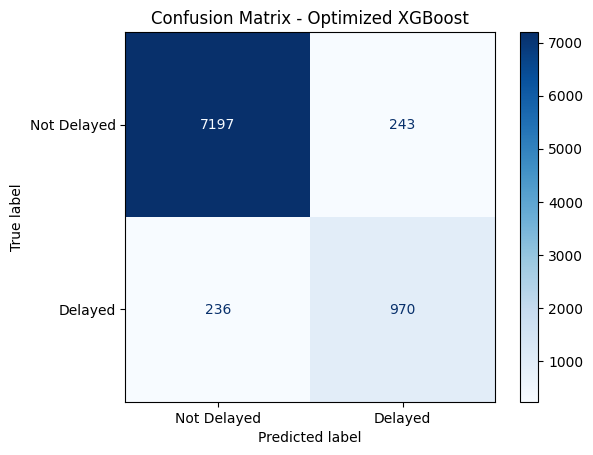

In [38]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Delayed', 'Delayed'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Optimized XGBoost')
plt.show()

## ROC AUC Score

ROC AUC Score: 98.3014


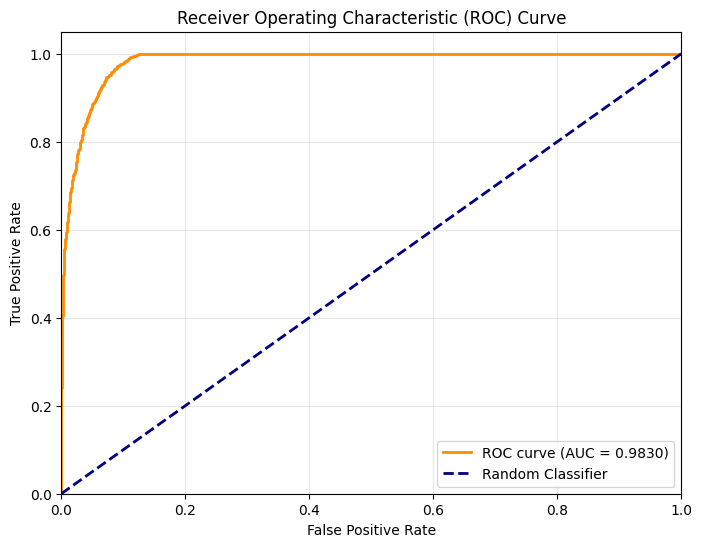

In [39]:
from sklearn.metrics import roc_auc_score, roc_curve

# Get prediction probabilities for ROC curve
y_pred_proba = pipe.predict_proba(x_test)[:, 1]

# Calculate ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f'ROC AUC Score: {100 * roc_auc:.4f}')

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Specificity and Sensitivity

In [40]:
# Calculate Specificity (True Negative Rate)
# Specificity = TN / (TN + FP)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)  # Also known as Recall or True Positive Rate

print(f'Specificity (True Negative Rate): {specificity:.4f} or {100 * specificity:.2f}%')
print(f'Sensitivity (True Positive Rate): {sensitivity:.4f} or {100 * sensitivity:.2f}%')

Specificity (True Negative Rate): 0.9673 or 96.73%
Sensitivity (True Positive Rate): 0.8043 or 80.43%


## Save the trained model

In [44]:
import pickle
import os
from datetime import datetime

# Create the saved_models directory if it doesn't exist
save_dir = '../saved_models/'
os.makedirs(save_dir, exist_ok=True)

# Create a timestamp for the filename
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_filename = os.path.join(save_dir, f'XGBoost_model_{timestamp}.pkl')

# Save the entire pipeline (preprocessor + model)
with open(model_filename, 'wb') as file:
    pickle.dump(pipe, file)

print(f"Model saved successfully as: {model_filename}")

# Also save the best parameters for reference
params_filename = os.path.join(save_dir, f'XGB_BestParams_JFKFlightTakeoff_{timestamp}.pkl')
with open(params_filename, 'wb') as file:
    pickle.dump(study.best_params, file)

print(f"Best parameters saved as: {params_filename}")

Model saved successfully as: ../saved_models/XGBoost_model_20251029_003221.pkl
Best parameters saved as: ../saved_models/XGB_BestParams_JFKFlightTakeoff_20251029_003221.pkl


### Load the model (example)
To load the model later, use the following code:

In [ ]:
# # Example: How to load the saved model
# import pickle

# # Load the model
# with open('xgboost_model_YYYYMMDD_HHMMSS.pkl', 'rb') as file:
#     loaded_pipe = pickle.load(file)

# # Load the best parameters
# with open('best_params_YYYYMMDD_HHMMSS.pkl', 'rb') as file:
#     loaded_params = pickle.load(file)

# # Use the loaded model for predictions
# # predictions = loaded_pipe.predict(new_data)
# print("Model loaded successfully!")